<a href="https://colab.research.google.com/github/Rugwiroparfait/ALX_ML/blob/main/Case_Study_UCI_Bank_Marketing_Dataset_Part_2_(Classification_Models).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# UCI Bank Marketing Dataset. Case study. Part 2 (Classification Models)

**Abstract:**

This notebook is a direct continuation of [Part 1 (EDA)](./Case%20Study%20-%20UCI%20Bank%20Marketing%20Dataset%20-%20Part%201%20(EDA).ipynb), in which we thoroughly explored the UCI Bank Marketing dataset. The data originates from direct marketing campaigns (phone calls) of a Portuguese banking institution, and the classification goal remains: **predict whether a client will subscribe to a term deposit** (variable `y`).

In this Part 2, we move from exploration to **model building**. Specifically, we will:

1. Briefly summarise the findings from Part 1 (EDA), particularly the feature analysis
2. Perform **feature engineering** early and in a logical, structured order
3. Build **tree-based classification models**: Decision Trees and Random Forests
4. Build **Support Vector Machine (SVM)** classifiers
5. Evaluate and compare all models

**Source:** [UCI Machine Learning Repository – Bank Marketing](https://archive.ics.uci.edu/ml/datasets/bank+marketing)

[Moro et al., 2014] S. Moro, P. Cortez and P. Rita. *A Data-Driven Approach to Predict the Success of Bank Telemarketing.* Decision Support Systems, Elsevier, 62:22-31, June 2014

# Recap of Part 1 (EDA)

## Dataset overview

We used the `bank-additional-full.csv` dataset containing **41,188 observations** and **21 columns** (20 input features + 1 target). The data is ordered chronologically from **May 2008 to November 2010**.

The target variable `y` (subscribed term deposit: yes / no) is **heavily imbalanced**: approximately **88% "no"** vs. **12% "yes"**.

## Feature analysis summary

The features were analysed in four groups:

### Bank client data
| Feature | Type | Key finding |
|:---|:---|:---|
| `age` | numeric | Older (60+) and younger (<30) clients show higher yes-rates |
| `job` | categorical | Students and retirees have the highest subscription rates |
| `marital` | categorical | Single clients are slightly more likely to subscribe |
| `education` | categorical | Those with university degrees subscribe at a higher rate |
| `default` | categorical | Overwhelmingly "no" or "unknown"; very few have credit in default |
| `housing` | categorical | Roughly equal split; those without housing loans subscribe slightly more |
| `loan` | categorical | Most clients don't have a personal loan; those without are slightly more likely to subscribe |

### Last contact of the current campaign
| Feature | Type | Key finding |
|:---|:---|:---|
| `contact` | categorical | Cellular contact yields significantly higher yes-rates than telephone |
| `month` | categorical | March, September, October, and December show the highest yes-proportions |
| `day_of_week` | categorical | No significant effect on the outcome |
| `duration` | numeric | Strongest individual correlation with `y` (0.41). **However, `duration` is not known before a call and should be excluded from realistic predictive models.** |

### Other attributes
| Feature | Type | Key finding |
|:---|:---|:---|
| `campaign` | numeric | Fewer contacts → higher yes-rate |
| `pdays` | numeric | 999 means not previously contacted (96%+ of records); those previously contacted have much higher yes-rates |
| `previous` | numeric | More previous contacts → higher yes-rate |
| `poutcome` | categorical | Previous campaign success leads to extremely high yes-rate (~65%) |

### Social and economic context
| Feature | Type | Key finding |
|:---|:---|:---|
| `emp.var.rate` | numeric | Negatively correlated with `y` (-0.30); lower employment variation rate → more subscriptions |
| `cons.price.idx` | numeric | Weak negative correlation |
| `cons.conf.idx` | numeric | Weak positive correlation |
| `euribor3m` | numeric | Strongly negatively correlated (-0.31); lower Euribor rate → more subscriptions |
| `nr.employed` | numeric | Strongly negatively correlated (-0.35); fewer employees → more subscriptions |

> **Critical note from Part 1:** The `duration` feature should be dropped for any realistic predictive model, since it is only known after the call ends — at which point the outcome `y` is already determined.

# Data Loading and Initial Setup

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report,
    ConfusionMatrixDisplay, RocCurveDisplay
)

import warnings
warnings.filterwarnings('ignore')

sns.set_style('darkgrid')
sns.set_theme(font_scale=1.1)

RANDOM_STATE = 42
print('Libraries loaded successfully.')

Libraries loaded successfully.


In [ ]:
# Load the same dataset used in Part 1
df = pd.read_csv('data/bank-additional-full.csv', sep=';')
print(f'Dataset shape: {df.shape}')
df.head()

Dataset shape: (41188, 21)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

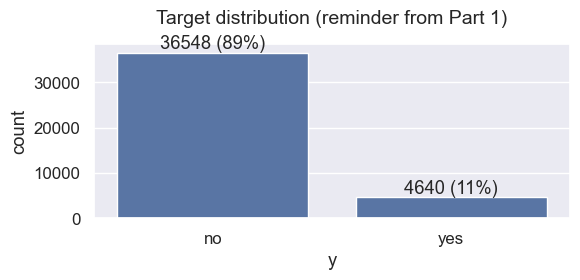

In [ ]:
# Quick look at the target distribution (as a reminder)
fig, ax = plt.subplots(figsize=(6, 3))
sns.countplot(x=df['y'], ax=ax)

abs_vals = df['y'].value_counts()
rel_vals = df['y'].value_counts(normalize=True) * 100
labels = [f'{p[0]} ({p[1]:.0f}%)' for p in zip(abs_vals, rel_vals)]
ax.bar_label(container=ax.containers[0], labels=labels)
ax.set_title('Target distribution (reminder from Part 1)', fontsize=14, pad=15)
plt.tight_layout()
plt.show()

# Feature Engineering

Following the logical structure of Part 1, we perform all feature engineering steps **before** model training. This includes:

1. Target encoding (`y`: yes/no → 1/0)
2. Dropping the `duration` feature (as discussed in Part 1)
3. Engineering the `pdays` feature
4. Encoding categorical variables
5. Feature scaling (for SVM)
6. Train-test split

## Step 1: Target encoding

In [ ]:
# Encode the target variable
df['y'] = df['y'].map({'no': 0, 'yes': 1})
print(f'Target distribution after encoding:\n{df["y"].value_counts()}')

Target distribution after encoding:
y
0    36548
1     4640
Name: count, dtype: int64


## Step 2: Drop `duration`

As noted in Part 1 and in the dataset documentation:

> *"This attribute highly affects the output target (e.g., if duration=0 then y='no'). Yet, the duration is not known before a call is performed. Also, after the end of the call y is obviously known. Thus, this input should only be included for benchmark purposes and should be discarded if the intention is to have a realistic predictive model."*

We drop `duration` to build a **realistic** model that could be used before a marketing call is made.

In [ ]:
df = df.drop(columns=['day_of_week', 'duration'])
print(f'Remaining columns ({len(df.columns)}): {list(df.columns)}')

Remaining columns (19): ['age', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'campaign', 'pdays', 'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'y']


## Step 3: Engineer the `pdays` feature

From Part 1, we know that `pdays` = 999 means the client was **not previously contacted**. Over 96% of records have this sentinel value, which makes `pdays` as a raw numeric feature problematic.

We'll create a **binary feature** `was_previously_contacted` (1 if pdays ≠ 999, else 0). We also keep a scaled version of `pdays` for those who were contacted, and set those who were not to 0.

In [ ]:
# Create a binary flag for previous contact
df['was_previously_contacted'] = (df['pdays'] != 999).astype(int)

# For pdays itself, replace 999 with 0 (so it doesn't dominate scaling)
df['pdays'] = df['pdays'].replace(999, 0)

print(f'Previously contacted distribution:\n{df["was_previously_contacted"].value_counts()}')
print(f'\npdays stats (after replacing 999 with 0):\n{df["pdays"].describe()}')

Previously contacted distribution:
was_previously_contacted
0    39673
1     1515
Name: count, dtype: int64

pdays stats (after replacing 999 with 0):
count    41188.000000
mean         0.221229
std          1.348874
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max         27.000000
Name: pdays, dtype: float64


## Step 4: Encode categorical variables

We use **one-hot encoding** (`pd.get_dummies`) for the categorical features, dropping the first category in each to avoid multicollinearity.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       41188 non-null  int64  
 1   job                       41188 non-null  object 
 2   marital                   41188 non-null  object 
 3   education                 41188 non-null  object 
 4   default                   41188 non-null  object 
 5   housing                   41188 non-null  object 
 6   loan                      41188 non-null  object 
 7   contact                   41188 non-null  object 
 8   month                     41188 non-null  object 
 9   campaign                  41188 non-null  int64  
 10  pdays                     41188 non-null  int64  
 11  previous                  41188 non-null  int64  
 12  poutcome                  41188 non-null  object 
 13  emp.var.rate              41188 non-null  float64
 14  cons.p

In [ ]:
# Identify categorical columns
cat_cols = df.select_dtypes(include='object').columns.tolist()
print(f'Categorical columns to encode: {cat_cols}')

# One-hot encode
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True, dtype=int)
print(f'\nDataset shape after encoding: {df_encoded.shape}')
df_encoded.head()

Categorical columns to encode: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']

Dataset shape after encoding: (41188, 50)


,age,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,...,month_dec,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_nonexistent,poutcome_success
0,56,1,0,0,1.1,93.994,-36.4,4.857,5191.0,0,...,0,0,0,0,1,0,0,0,1,0
1,57,1,0,0,1.1,93.994,-36.4,4.857,5191.0,0,...,0,0,0,0,1,0,0,0,1,0
2,37,1,0,0,1.1,93.994,-36.4,4.857,5191.0,0,...,0,0,0,0,1,0,0,0,1,0
3,40,1,0,0,1.1,93.994,-36.4,4.857,5191.0,0,...,0,0,0,0,1,0,0,0,1,0
4,56,1,0,0,1.1,93.994,-36.4,4.857,5191.0,0,...,0,0,0,0,1,0,0,0,1,0


## Step 5: Train-test split

We use an 80/20 split with **stratification** on the target variable to preserve the class ratio in both sets.

In [ ]:
# Separate features and target
X = df_encoded.drop(columns=['y'])
y = df_encoded['y']

# Stratified train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f'Training set: {X_train.shape[0]} samples')
print(f'Test set:     {X_test.shape[0]} samples')
print(f'\nTraining target distribution:\n{y_train.value_counts(normalize=True).round(3)}')
print(f'\nTest target distribution:\n{y_test.value_counts(normalize=True).round(3)}')

Training set: 32950 samples
Test set:     8238 samples

Training target distribution:
y
0    0.887
1    0.113
Name: proportion, dtype: float64

Test target distribution:
y
0    0.887
1    0.113
Name: proportion, dtype: float64


## Step 6: Feature scaling (for SVM)

SVMs are sensitive to feature scales, so we fit a `StandardScaler` on the training set and transform both train and test sets. We keep **separate** scaled versions so that tree-based models can use unscaled data (which they don't need scaling for).

In [ ]:
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

print('Scaling complete.')
print(f'Scaled training set stats (first 3 features):\n{X_train_scaled.iloc[:, :3].describe().round(2)}')

Scaling complete.
Scaled training set stats (first 3 features):
            age  campaign     pdays
count  32950.00  32950.00  32950.00
mean       0.00     -0.00     -0.00
std        1.00      1.00      1.00
min       -2.21     -0.57     -0.16
25%       -0.77     -0.57     -0.16
50%       -0.19     -0.20     -0.16
75%        0.67      0.16     -0.16
max        5.57     19.42     19.69


# Handling Class Imbalance

The target is heavily imbalanced (~88% no / ~12% yes). If we train naively, the models will simply predict "no" for almost everything and still achieve ~88% accuracy — which is misleading.

**Strategy:** We will use `class_weight='balanced'` in all our models. This tells scikit-learn to automatically adjust weights inversely proportional to class frequencies, effectively giving more importance to the minority class during training.

We will also pay close attention to **recall, F1-score, and ROC-AUC** rather than relying on accuracy alone.

# Helper functions for evaluation

In [ ]:
def evaluate_model(model, X_test, y_test, model_name='Model'):
    """
    Evaluate a classification model and print key metrics.
    Returns a dict with the metrics.
    """
    y_pred = model.predict(X_test)

    # For ROC-AUC, use predict_proba if available, else decision_function
    if hasattr(model, 'predict_proba'):
        y_prob = model.predict_proba(X_test)[:, 1]
    elif hasattr(model, 'decision_function'):
        y_prob = model.decision_function(X_test)
    else:
        y_prob = y_pred

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)

    print(f'\n{"=" * 50}')
    print(f'{model_name} — Evaluation Results')
    print(f'{"=" * 50}')
    print(f'Accuracy:  {acc:.4f}')
    print(f'Precision: {prec:.4f}')
    print(f'Recall:    {rec:.4f}')
    print(f'F1-Score:  {f1:.4f}')
    print(f'ROC-AUC:   {roc_auc:.4f}')
    print()
    print(classification_report(y_test, y_pred, target_names=['No', 'Yes']))

    # Confusion matrix
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=['No', 'Yes'], ax=axes[0])
    axes[0].set_title(f'{model_name} — Confusion Matrix')

    # ROC curve
    RocCurveDisplay.from_predictions(y_test, y_prob, ax=axes[1], name=model_name)
    axes[1].plot([0, 1], [0, 1], 'k--', lw=1, label='Random (AUC = 0.50)')
    axes[1].set_title(f'{model_name} — ROC Curve')
    axes[1].legend()
    plt.tight_layout()
    plt.show()

    return {
        'Model': model_name,
        'Accuracy': round(acc, 4),
        'Precision': round(prec, 4),
        'Recall': round(rec, 4),
        'F1-Score': round(f1, 4),
        'ROC-AUC': round(roc_auc, 4)
    }

In [ ]:
def plot_feature_importance(model, feature_names, top_n=15, title='Feature Importance'):
    """
    Plot the top N most important features from a tree-based model.
    """
    importances = model.feature_importances_
    indices = np.argsort(importances)[::-1][:top_n]

    fig, ax = plt.subplots(figsize=(10, 5))
    sns.barplot(x=importances[indices], y=[feature_names[i] for i in indices], ax=ax)
    ax.set_title(title, fontsize=14, pad=15)
    ax.set_xlabel('Importance')
    plt.tight_layout()
    plt.show()

In [ ]:
# We will collect results from all models here
results = []

# Decision Tree Classifier

Decision Trees are intuitive, interpretable models that recursively partition the feature space. Each internal node tests a feature, each branch represents the outcome, and each leaf assigns a class label.

**Key advantages:**
- Easy to interpret and visualise
- Handles both numerical and categorical data
- No feature scaling required

**Key disadvantages:**
- Prone to overfitting (especially deep trees)
- Sensitive to noisy data
- Can be unstable (small changes in data can lead to very different trees)

## Baseline Decision Tree


Decision Tree (Baseline) — Evaluation Results
Accuracy:  0.8443
Precision: 0.3194
Recall:    0.3384
F1-Score:  0.3286
ROC-AUC:   0.6242

              precision    recall  f1-score   support

          No       0.92      0.91      0.91      7310
         Yes       0.32      0.34      0.33       928

    accuracy                           0.84      8238
   macro avg       0.62      0.62      0.62      8238
weighted avg       0.85      0.84      0.85      8238



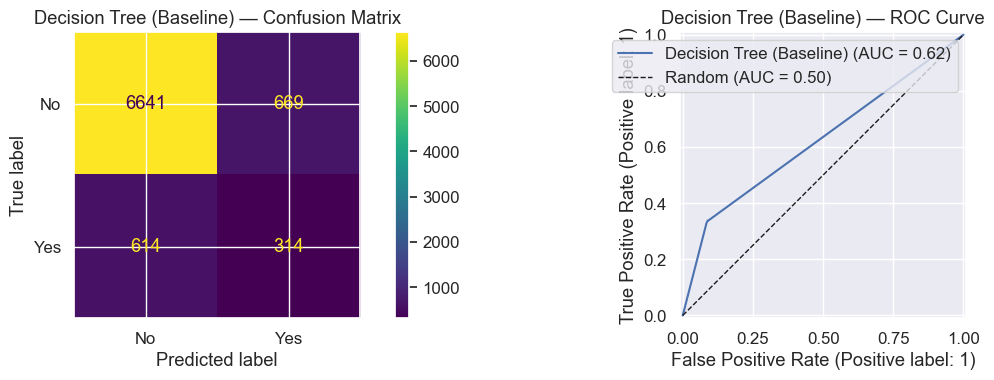

In [ ]:
dt_baseline = DecisionTreeClassifier(
    random_state=RANDOM_STATE,
    class_weight='balanced'
)
dt_baseline.fit(X_train, y_train)

dt_baseline_results = evaluate_model(dt_baseline, X_test, y_test, 'Decision Tree (Baseline)')
results.append(dt_baseline_results)

## Hyperparameter tuning

In [ ]:
dt_param_grid = {
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 5, 10],
    'criterion': ['gini', 'entropy']
}

dt_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=RANDOM_STATE, class_weight='balanced'),
    param_grid=dt_param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

dt_grid.fit(X_train, y_train)


print(f'\nBest parameters: {dt_grid.best_params_}')
print(f'Best CV F1 score: {dt_grid.best_score_:.4f}')

Fitting 5 folds for each of 160 candidates, totalling 800 fits

Best parameters: {'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 10, 'min_samples_split': 2}
Best CV F1 score: 0.4479



Decision Tree (Tuned) — Evaluation Results
Accuracy:  0.8403
Precision: 0.3761
Recall:    0.6347
F1-Score:  0.4723
ROC-AUC:   0.7927

              precision    recall  f1-score   support

          No       0.95      0.87      0.91      7310
         Yes       0.38      0.63      0.47       928

    accuracy                           0.84      8238
   macro avg       0.66      0.75      0.69      8238
weighted avg       0.88      0.84      0.86      8238



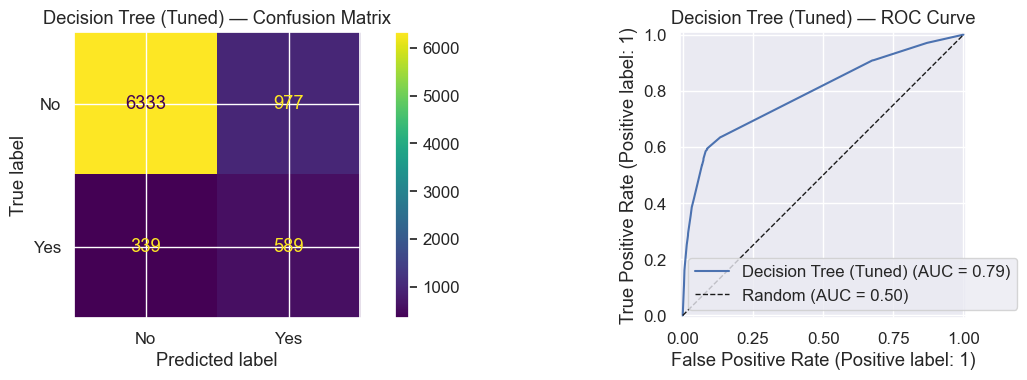

In [ ]:
dt_best = dt_grid.best_estimator_
dt_best_results = evaluate_model(dt_best, X_test, y_test, 'Decision Tree (Tuned)')
results.append(dt_best_results)

## Decision Tree visualisation

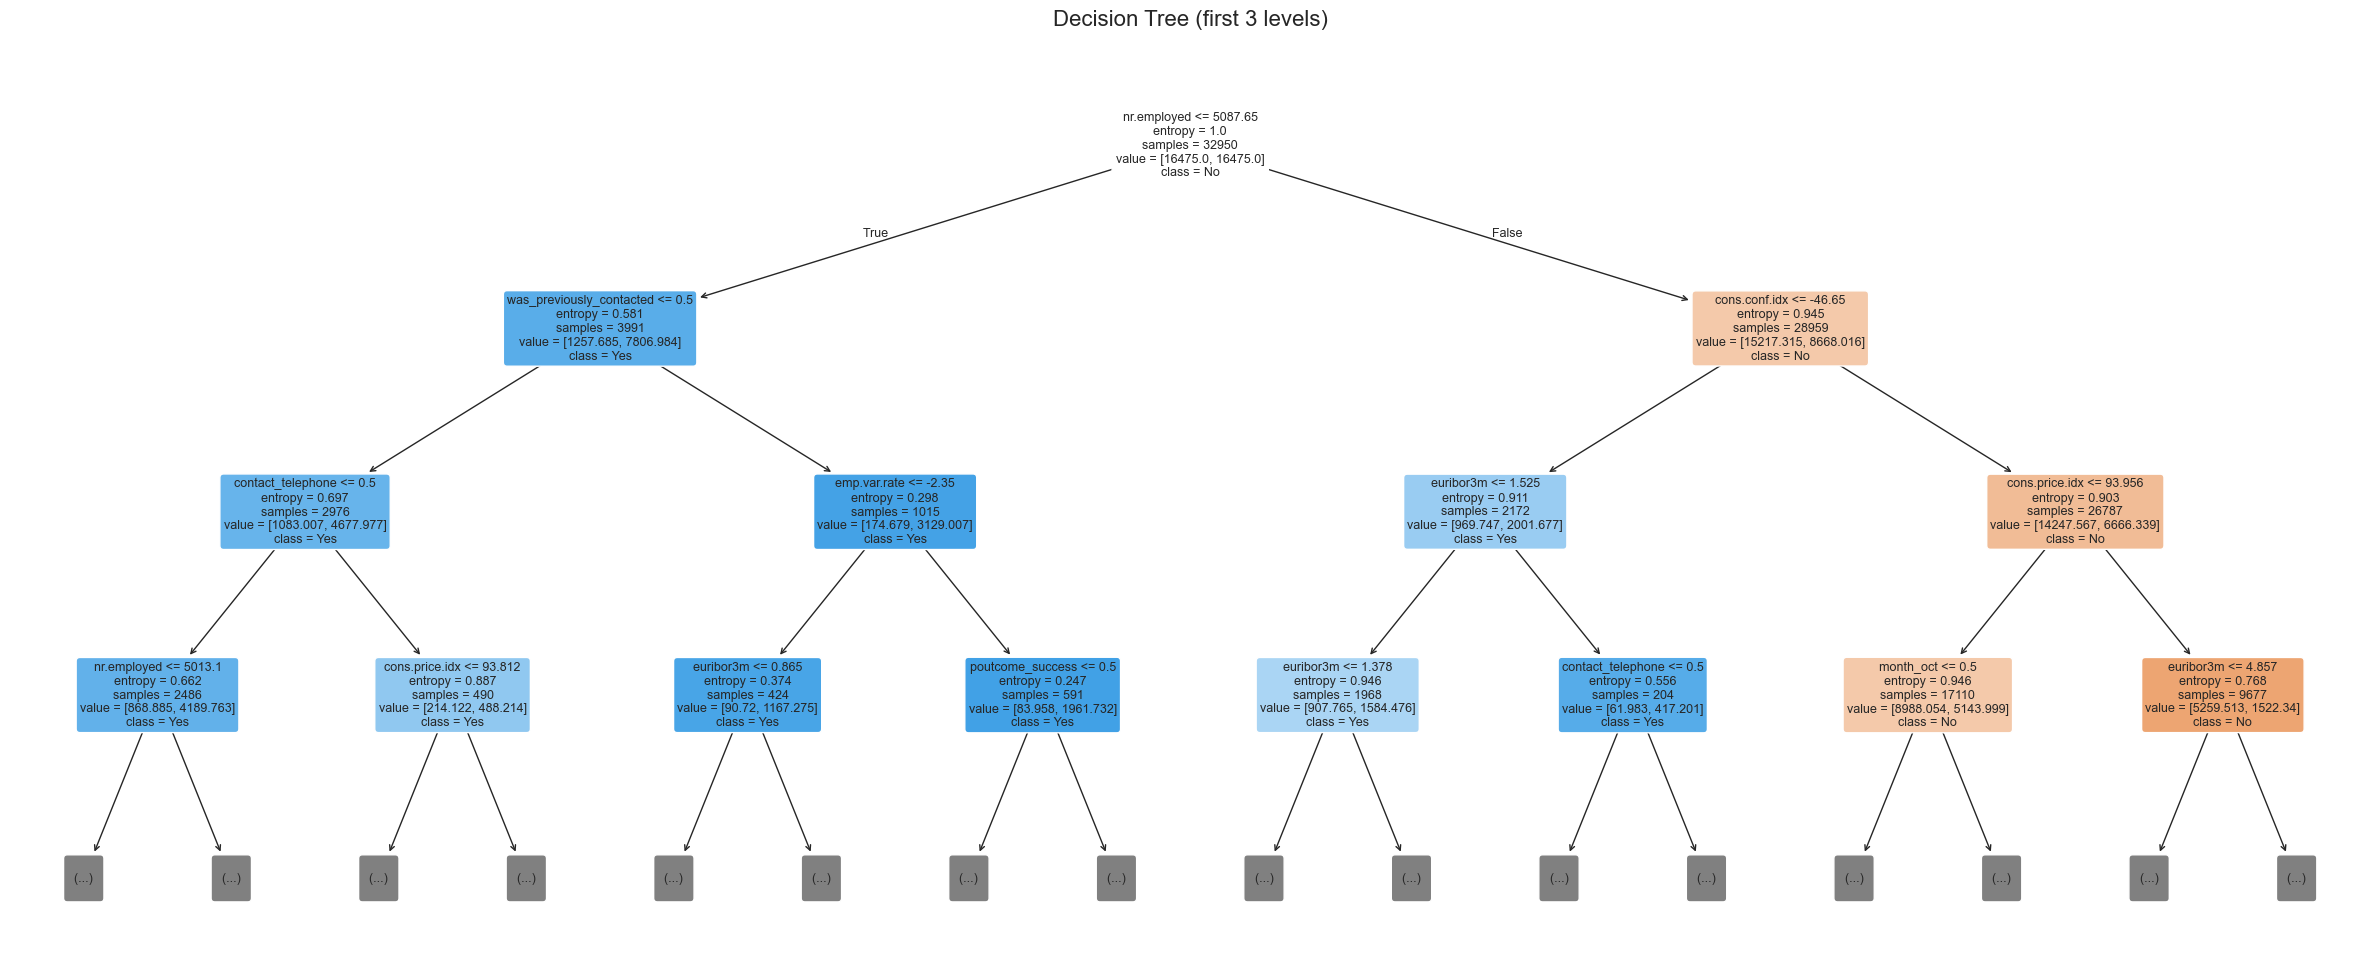

In [ ]:
fig, ax = plt.subplots(figsize=(24, 10))
plot_tree(
    dt_best,
    feature_names=X_train.columns,
    class_names=['No', 'Yes'],
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=9,
    ax=ax
)
ax.set_title('Decision Tree (first 3 levels)', fontsize=16, pad=20)
plt.tight_layout()
plt.show()

## Feature importance (Decision Tree)

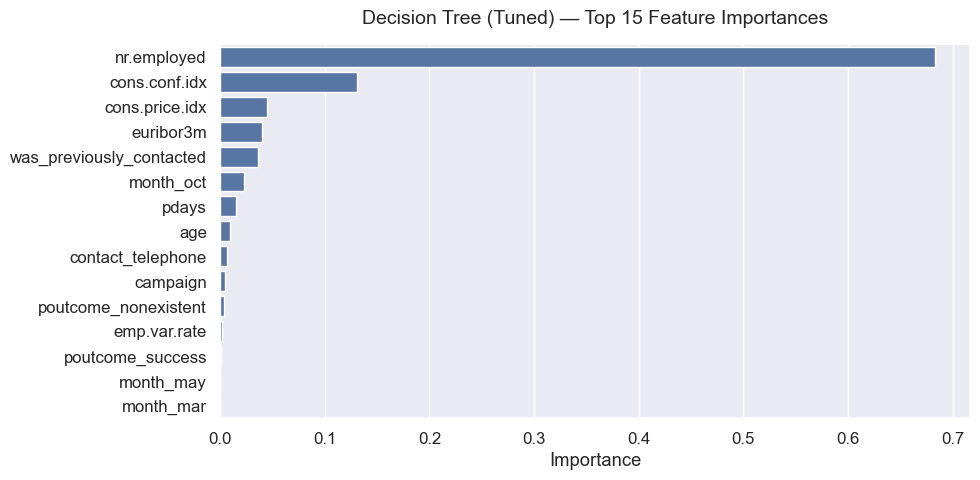

In [ ]:
plot_feature_importance(
    dt_best, X_train.columns.tolist(),
    top_n=15,
    title='Decision Tree (Tuned) — Top 15 Feature Importances'
)

# Random Forest Classifier

Random Forests are an **ensemble** of many Decision Trees trained on different bootstrap samples of the data, with random subsets of features considered at each split. The final prediction is determined by **majority vote**.

**Key advantages over a single Decision Tree:**
- Significantly reduces overfitting by averaging many trees
- More robust to noisy data
- Provides reliable feature importance estimates

**Key disadvantages:**
- Less interpretable than a single tree
- More computationally expensive

## Baseline Random Forest


Random Forest (Baseline) — Evaluation Results
Accuracy:  0.8961
Precision: 0.5759
Recall:    0.2942
F1-Score:  0.3894
ROC-AUC:   0.7734

              precision    recall  f1-score   support

          No       0.92      0.97      0.94      7310
         Yes       0.58      0.29      0.39       928

    accuracy                           0.90      8238
   macro avg       0.75      0.63      0.67      8238
weighted avg       0.88      0.90      0.88      8238



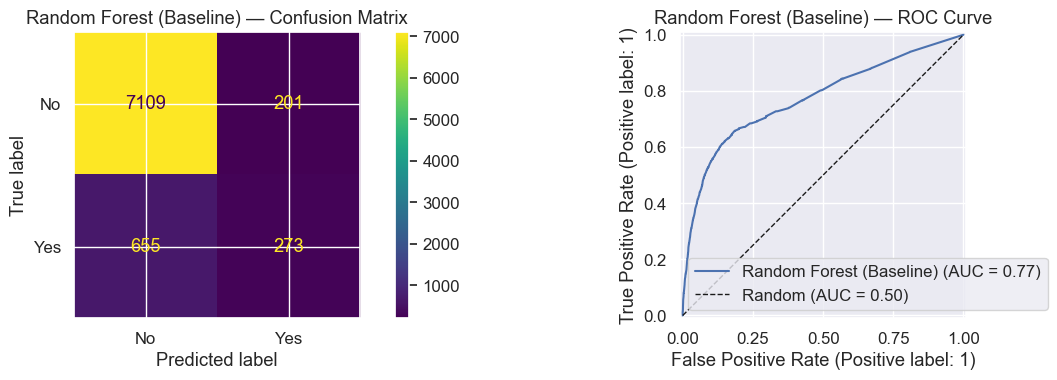

In [ ]:
rf_baseline = RandomForestClassifier(
    n_estimators=100,
    random_state=RANDOM_STATE,
    class_weight='balanced',
    n_jobs=-1
)
rf_baseline.fit(X_train, y_train)

rf_baseline_results = evaluate_model(rf_baseline, X_test, y_test, 'Random Forest (Baseline)')
results.append(rf_baseline_results)

## Hyperparameter tuning

In [ ]:
rf_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'max_features': ['sqrt', 'log2']
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE, class_weight='balanced', n_jobs=-1),
    param_grid=rf_param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

rf_grid.fit(X_train, y_train)

print(f'\nBest parameters: {rf_grid.best_params_}')
print(f'Best CV F1 score: {rf_grid.best_score_:.4f}')

Fitting 5 folds for each of 72 candidates, totalling 360 fits

Best parameters: {'max_depth': 15, 'max_features': 'sqrt', 'min_samples_split': 10, 'n_estimators': 100}
Best CV F1 score: 0.4917



Random Forest (Tuned) — Evaluation Results
Accuracy:  0.8742
Precision: 0.4565
Recall:    0.6099
F1-Score:  0.5221
ROC-AUC:   0.8122

              precision    recall  f1-score   support

          No       0.95      0.91      0.93      7310
         Yes       0.46      0.61      0.52       928

    accuracy                           0.87      8238
   macro avg       0.70      0.76      0.72      8238
weighted avg       0.89      0.87      0.88      8238



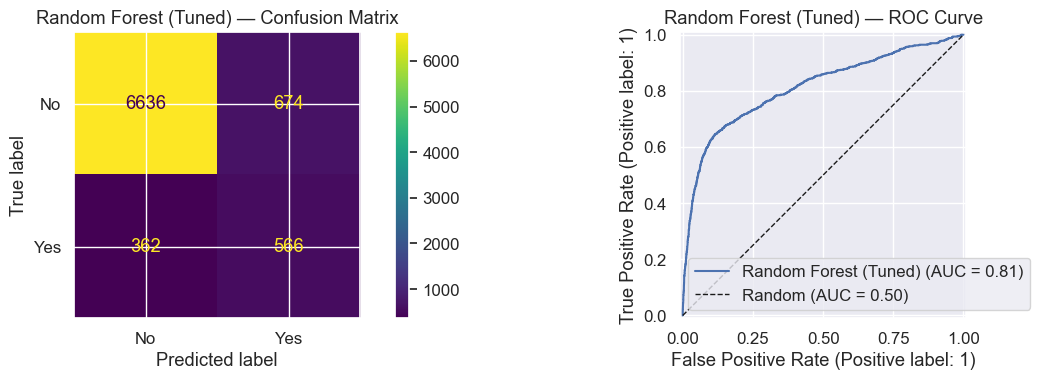

In [ ]:
rf_best = rf_grid.best_estimator_
rf_best_results = evaluate_model(rf_best, X_test, y_test, 'Random Forest (Tuned)')
results.append(rf_best_results)

## Feature importance (Random Forest)

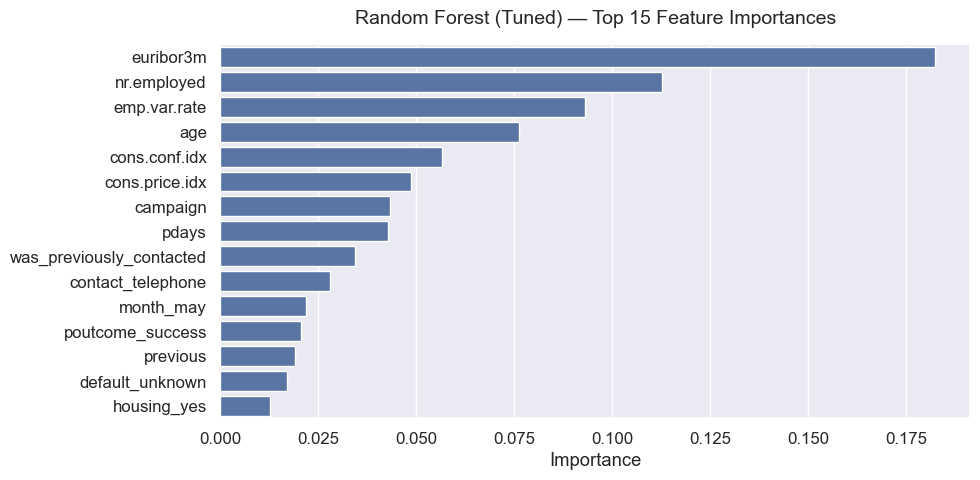

In [ ]:
plot_feature_importance(
    rf_best, X_train.columns.tolist(),
    top_n=15,
    title='Random Forest (Tuned) — Top 15 Feature Importances'
)

# Support Vector Machine (SVM)

SVMs find the **optimal hyperplane** that maximally separates the two classes in a high-dimensional feature space. Using the *kernel trick*, SVMs can model complex, non-linear decision boundaries.

**Key advantages:**
- Effective in high-dimensional spaces
- Versatile through different kernel functions (linear, RBF, polynomial)
- Memory-efficient (uses only support vectors)

**Key disadvantages:**
- Sensitive to feature scaling (requires standardisation)
- Computationally expensive on large datasets
- Not naturally probabilistic; probabilities require additional computation

> **Note:** We use the **scaled** versions of the training and test sets for SVM.

## SVM with Linear Kernel

In [ ]:
svm_linear = SVC(
    kernel='linear',
    class_weight='balanced',
    random_state=RANDOM_STATE,
    probability=True
)
svm_linear.fit(X_train_scaled, y_train)

svm_linear_results = evaluate_model(svm_linear, X_test_scaled, y_test, 'SVM (Linear Kernel)')
results.append(svm_linear_results)

## SVM with RBF Kernel

In [ ]:
svm_rbf = SVC(
    kernel='rbf',
    class_weight='balanced',
    random_state=RANDOM_STATE,
    probability=True
)
svm_rbf.fit(X_train_scaled, y_train)

svm_rbf_results = evaluate_model(svm_rbf, X_test_scaled, y_test, 'SVM (RBF Kernel)')
results.append(svm_rbf_results)

## SVM hyperparameter tuning (RBF)

We tune `C` (regularisation) and `gamma` (kernel coefficient) for the RBF kernel.

In [ ]:
svm_param_grid = {
    'C': [0.1, 1, 10],
    'gamma': ['scale', 'auto', 0.01, 0.1]
}

svm_grid = GridSearchCV(
    SVC(kernel='rbf', class_weight='balanced', random_state=RANDOM_STATE, probability=True),
    param_grid=svm_param_grid,
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE),
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

svm_grid.fit(X_train_scaled, y_train)

print(f'\nBest parameters: {svm_grid.best_params_}')
print(f'Best CV F1 score: {svm_grid.best_score_:.4f}')

In [ ]:
svm_best = svm_grid.best_estimator_
svm_best_results = evaluate_model(svm_best, X_test_scaled, y_test, 'SVM (Tuned RBF)')
results.append(svm_best_results)

# Model Comparison

In [ ]:
# Create comparison table
results_df = pd.DataFrame(results)
results_df = results_df.set_index('Model')
results_df = results_df.sort_values('F1-Score', ascending=False)

print('Model Comparison (sorted by F1-Score):')
print('=' * 80)
results_df

In [ ]:
# Visualise comparison
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']

fig, axes = plt.subplots(1, len(metrics_to_plot), figsize=(20, 5))

for i, metric in enumerate(metrics_to_plot):
    ax = axes[i]
    vals = results_df[metric]
    colors = sns.color_palette('viridis', n_colors=len(vals))
    ax.barh(vals.index, vals.values, color=colors)
    ax.set_title(metric, fontsize=13)
    ax.set_xlim(0, 1)
    for j, v in enumerate(vals.values):
        ax.text(v + 0.01, j, f'{v:.3f}', va='center', fontsize=9)

plt.suptitle('Model Comparison across Metrics', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

## ROC curves overlay

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))

# Models and their test data pairings
models_to_plot = [
    (dt_best, X_test, 'Decision Tree (Tuned)'),
    (rf_best, X_test, 'Random Forest (Tuned)'),
    (svm_best, X_test_scaled, 'SVM (Tuned RBF)'),
]

for model, X_data, name in models_to_plot:
    if hasattr(model, 'predict_proba'):
        y_prob = model.predict_proba(X_data)[:, 1]
    else:
        y_prob = model.decision_function(X_data)

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    ax.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random (AUC = 0.500)')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — Model Comparison', fontsize=14, pad=15)
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

# Conclusion

In this Part 2, we moved from the exploratory analysis of Part 1 to building and evaluating classification models on the UCI Bank Marketing dataset.

**Key takeaways:**

1. **Feature engineering matters.** Dropping `duration` (which leaks target information) and engineering `pdays` into a binary contact flag resulted in a more realistic and honest modelling setup.

2. **Class imbalance must be addressed.** Using `class_weight='balanced'` was critical — without it, models would simply predict the dominant class ("no") and achieve misleadingly high accuracy.

3. **Decision Trees** provided interpretable results and decent performance, but showed signs of overfitting without proper regularisation through hyperparameter tuning.

4. **Random Forests** — as an ensemble of decision trees — generally outperformed single decision trees, offering better generalisation and more stable feature importance rankings.

5. **SVMs** with scaled features and the RBF kernel demonstrated strong discriminative capability, though at a higher computational cost.

6. **Feature importance** was consistent across tree-based models, with socio-economic indicators (`nr.employed`, `euribor3m`, `emp.var.rate`) and campaign-related features (`pdays`, `poutcome`) ranking highly — aligning with the EDA findings from Part 1.

**Recommendations for future work:**
- Experiment with gradient boosting methods (XGBoost, LightGBM)
- Apply SMOTE or other re-sampling techniques for class imbalance
- Explore more advanced feature engineering (interaction terms, polynomial features)
- Perform a more exhaustive hyperparameter search using Bayesian optimisation